In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [76]:
#load dataset
housing=fetch_california_housing()

data=pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"]=housing.target

In [77]:
#select one feature
x=data[['AveRooms']].values
y=data['Price'].values

In [78]:
#split data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=43)

In [79]:
#FEATURE SCALING
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [80]:
w = 0
b = 0
learning_rate = 0.02
epochs = 1000

n = len(x_train_scaled)

cost_history = []

for i in range(epochs):
    y_pred = w * x_train_scaled.flatten() + b

    cost = (1/(2*n)) * np.sum((y_pred - y_train) ** 2)
    cost_history.append(cost)

    dw = (1/n) * np.sum((y_pred - y_train) * x_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)

    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
        print(f"Epoch {i}, Cost = {cost:.4f}")

Epoch 0, Cost = 2.8035
Epoch 100, Cost = 0.6889
Epoch 200, Cost = 0.6517
Epoch 300, Cost = 0.6510
Epoch 400, Cost = 0.6510
Epoch 500, Cost = 0.6510
Epoch 600, Cost = 0.6510
Epoch 700, Cost = 0.6510
Epoch 800, Cost = 0.6510
Epoch 900, Cost = 0.6510


In [81]:
 #Normal Equation
x_train_ne=np.c_[np.ones((len(x_train),1)),x_train]
x_test_ne=np.c_[np.ones((len(x_test),1)),x_test]

theta=np.linalg.inv(x_train_ne.T @ x_train_ne) @ x_train_ne.T @ y_train
y_pred_ne = x_test_ne @theta 

In [82]:
print("\n Normal Equation")
print("------------------")
print("Intercept:",theta[0])
print("Slope:",theta[1])
print("MSE:",mean_squared_error(y_test,y_pred_ne))
print("R2 SCORE:",r2_score(y_test,y_pred_ne))



 Normal Equation
------------------
Intercept: 1.7075968603854665
Slope: 0.06636486215262562
MSE: 1.2966793984184621
R2 SCORE: 0.02759946401211988


In [83]:
#sort values for smooth regression line

sort_axis=np.argsort(x_test.flatten())
x_sorted =x_test[sort_axis]
y_pred_ne_sorted=y_pred_ne[sort_axis]

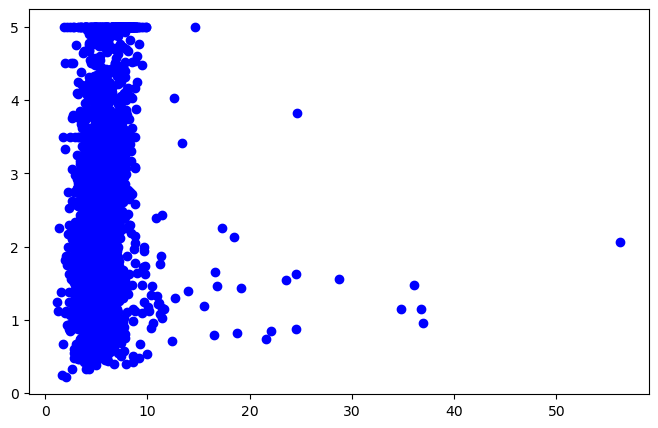

In [84]:
#Regression k=line visualization


index=np.argsort(x_test.flatten())
plt.figure(figsize=(8,5))
#scatter plot
plt.scatter(x_test,y_test,color='blue',label='Actual data')

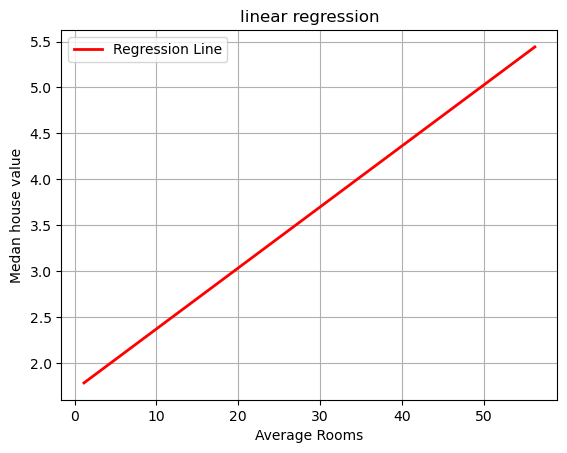

In [85]:
#Regression line
plt.plot(
     x_test.flatten()[index],y_pred_ne[index],color='red',linewidth=2,label='Regression Line'
)
plt.title("linear regression")
plt.xlabel("Average Rooms")
plt.ylabel("Medan house value")
plt.legend()
plt.grid(True)
plt.show()

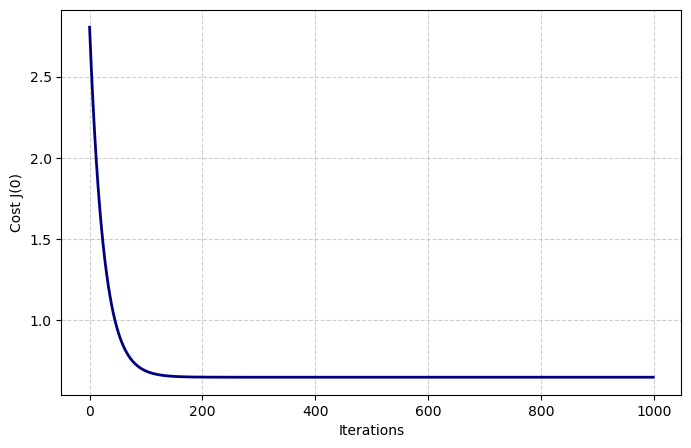

In [86]:
#cost convergence curve

plt.figure(figsize=(8,5))
plt.plot(cost_history,color='navy',linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('Cost J(0)')
plt.grid(True,linestyle='--',alpha=0.6)

plt.show()